In [24]:
import numpy as np
from scipy.sparse import coo_matrix

In [25]:
# first we will see what kind of data we have to deal with
import zipfile

with zipfile.ZipFile("hs_tomography.zip", "r") as zip_ref:
    zip_ref.printdir()
    zip_ref.extractall(".")

File Name                                             Modified             Size
hs_tomography/                                 2017-11-29 10:23:08            0
hs_tomography/alphas_195.npy                   2015-12-01 20:41:58         1512
hs_tomography/alphas_77.npy                    2015-12-01 20:41:58          800
hs_tomography/info.txt                         2017-11-29 17:08:42          516
hs_tomography/X_77.npy                         2017-11-29 10:23:08     10519326
hs_tomography/X_example.npy                    2017-11-29 09:57:16        18080
hs_tomography/y_195.npy                        2015-12-01 20:41:58       393880
hs_tomography/y_77.npy                         2015-12-01 20:41:58        39320


Note: 
> .npy files are numpy files saved on disk for future use.

# 1 Constructing the matrix X

In [26]:
# alphas_195 = np.load("./hs_tomography/alphas_195.npy")
# alphas_77 = np.load("./hs_tomography/alphas_77.npy")

In [52]:
def construct_X(M, alphas, Np = None):
    # if Np was not given we chose Np = [sqrt(2).M]
    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        # choosing odd number 
        if Np % 2 == 0:
            Np += 1

    D = M * M
    N_angles = len(alphas)
    N = N_angles * Np


    # pixel coordinates
    x = np.arange(M) - (M - 1) / 2.0
    y = np.arange(M) - (M - 1) / 2.0

    # 2D grid and then flatten
    Xgrid, Ygrid = np.meshgrid(x, y, indexing='xy')
    coords = np.stack([Xgrid.ravel(), Ygrid.ravel()])   #shape -> (2, D)

    # p = n.T * C + S0

    # Pre-allocate lists for 
    rows_list = []
    columns_list = []
    data_list = []

    # loop over angels
    for indexOf, alpha in enumerate(alphas):
        rad = np.radians(alpha)
        
        # Sensor direction (unit vector along the sensor array)
        n = np.array([np.cos(rad), np.sin(rad)])

        # projection of each pixel onto the sensor line
        # n = (cos(alpha), sin(alpha))
        # projection_of_x_y_on_n = x.cos(alpha) + y.sin(alpha)
        p = n[0] * coords[0] + n[1] * coords[1]     # shape(D, )
        
        # x = p + (Np - 1)/2
        # map to sensor index -> with centre element at index (Np - 1)/2
        idx_float = p + (Np - 1) / 2.0

        # left and right indices for interpolation
        i_left = np.floor(idx_float).astype(np.int32)
        i_right = i_left + 1
        frac = idx_float - i_left  #fraction to the right

        # validate indices and save them for left and right
        left_ok = (i_left >= 0) & (i_left < Np)
        right_ok = (i_right >= 0) & (i_right < Np)

        # left indices
        if np.any(left_ok):
            rows_list.append(indexOf * Np + i_left[left_ok])
            columns_list.append(np.arange(D)[left_ok])
            data_list.append((1.0 - frac[left_ok]).astype(np.float32))

        if np.any(right_ok):
            rows_list.append(indexOf * Np + i_right[right_ok])
            columns_list.append(np.arange(D)[right_ok])
            data_list.append(frac[right_ok].astype(np.float32))

    rows = np.concatenate(rows_list)
    columns = np.concatenate(columns_list)
    data = np.concatenate(data_list)

    X = coo_matrix((data, (rows, columns)), shape=(N, D), dtype=np.float32)
    return X.tocsc()

In [53]:
import matplotlib.pyplot as plt

Max absolute difference: 9.98e-01
Are they exactly equal (allowing tiny floating error)? False


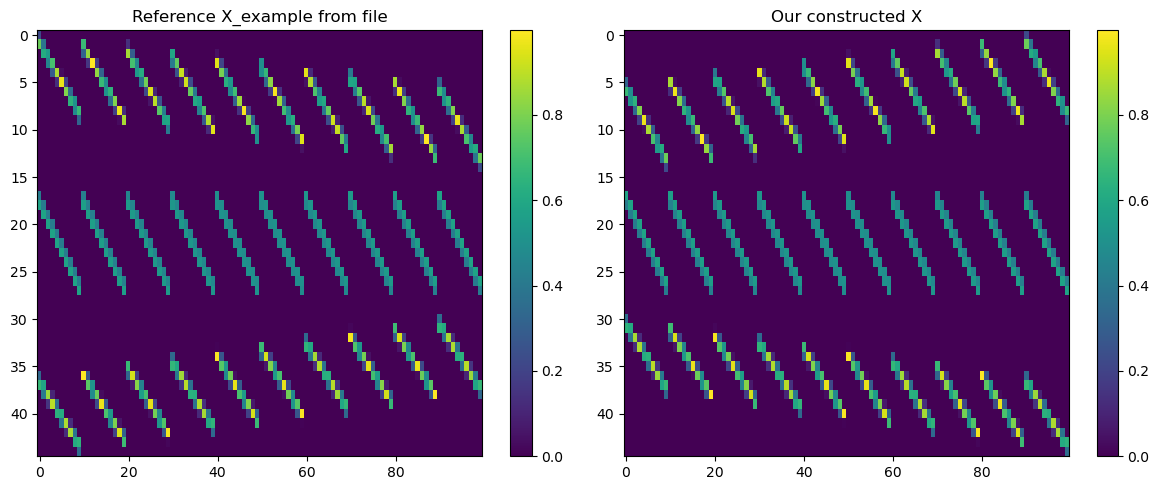

In [54]:
X_examaple = np.load("./hs_tomography/X_example.npy")

# Build the matrix X for m=10 and given angles
M_test = 10
alphas_test = np.array([-33, 1, 42])
Np_test = 15

X_us = construct_X(M_test, alphas_test, Np_test)
X_us_dense = X_us.toarray()

diff = np.abs(X_us_dense - X_examaple)
print(f"Max absolute difference: {diff.max():.2e}")
print("Are they exactly equal (allowing tiny floating error)?", np.allclose(X_us_dense, X_examaple, atol=1e-6))


# Visualize both of them
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.imshow(X_examaple, cmap='viridis', aspect='auto')
ax1.set_title('Reference X_example from file')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(X_us_dense, cmap='viridis', aspect='auto')
ax2.set_title('Our constructed X')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

#### End of Task 1 

# Task 2 - Recovering the Image

smaller -> { M = 77, Np = 109, 99 projection angles } 
larger -> { M = 195, Np = 275, 179 projection angles }

smaller version for debugging the code 

 Use scipy's tools to find out and report the sparsity of X 

In [55]:
from scipy.sparse import csr_matrix

In [56]:
alphas_77 = np.load('./hs_tomography/alphas_77.npy')
y_77 = np.load('./hs_tomography/y_77.npy')

M = 77
Np = 109   

In [59]:
print(f"Data I am using for debugging: \n")
print(f"Image size: {M} x {M}")
print(f"Number of angles: {len(alphas_77)}")
print(f"Sensor bins: {Np}")
print(f"Total measurements: {len(y_77)}")

Data I am using for debugging: 

Image size: 77 x 77
Number of angles: 90
Sensor bins: 109
Total measurements: 9810


In [60]:
import time

In [61]:
print(f"Building X: ")

start_time = time.time()
X = construct_X(M, alphas_77, Np)
print(f"Done in {time.time()-start_time:.1f} seconds.")
print(f"Shape: {X.shape}")
print(f"Non-zero entries: {X.nnz}")

Building X: 
Done in 0.0 seconds.
Shape: (9810, 5929)
Non-zero entries: 1067220


In [68]:
# to find sparsity, we need to calculate the ratio of zero valued elements in the sparse matrix to
# the total number of elements in the matrix

# 1 - (X.nnz / np.prod(X.shape))
# or I found this on internet -> 1- (X.nnz / (X.shape[0] * X.shape[1]))

sparsity = 1 - (X.nnz / np.prod(X.shape))
print(f"Sparsity of the matrix X: {sparsity:.4f}")
print(f"Percentage of zero elements: {sparsity*100:.2f}%")

Sparsity of the matrix X: 0.9817
Percentage of zero elements: 98.17%


In [66]:
print(f"Sparsity: {1 - X.nnz / (X.shape[0] * X.shape[1]):.4%}")

Sparsity: 98.1651%


In [69]:
## I dont know why they slightly differ, I asked in the discord to get others help for that

In [70]:
# We have to solve the equation system now
# the_real_image = inv(X_transpose * X) * X_transpose * y

# Find the least-squares solution to a large, sparse, linear system of equations
#  scipy.sparse.linalg.lsqr()

from scipy.sparse.linalg import lsqr

print(f"Solving the equation system using least-squares solution: ")
start_time = time.time()

# atol/btol = 1e-5 
beta, istop, itn, r1norm, r2norm, anorm, acond, arnorm, xnorm, var = lsqr(
    X, y_77, atol=1e-5, btol=1e-5
)



Solving the equation system using least-squares solution: 


In [72]:
print(f"Solved in {time.time()-start_time:.1f} seconds.")
print(f"Iterations: {itn}")
print(f"Residual norm: {r2norm:.2e}")


Solved in 11.8 seconds.
Iterations: 276
Residual norm: 6.19e+01


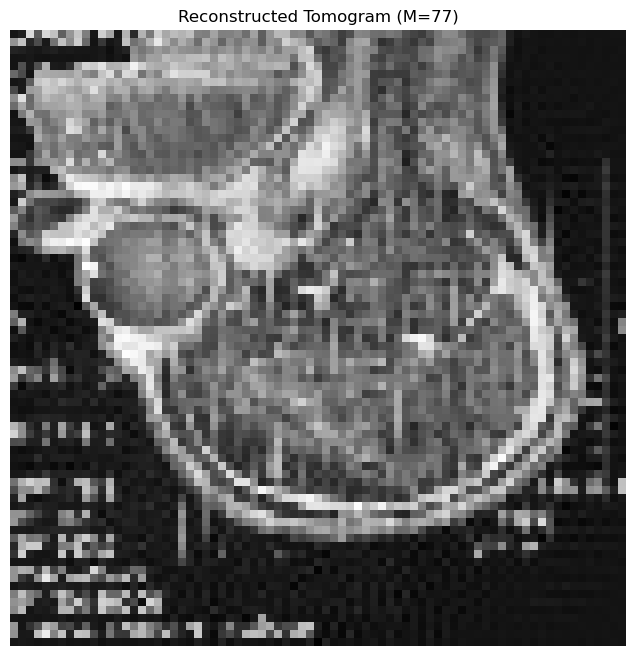

In [75]:
# Reshape to 2D image
img = beta.reshape(M, M)

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title("Reconstructed Tomogram (M=77)")
plt.axis('off')
plt.show()

Large image: 195 x 195
Angles: 179
Measurements: 49225

Building X for large dataset: 
Done in 0.2 seconds.
Non-zeros: 13612930
Sparsity: 99.2727%

Solving large system ...
Solved in 7.0 seconds.


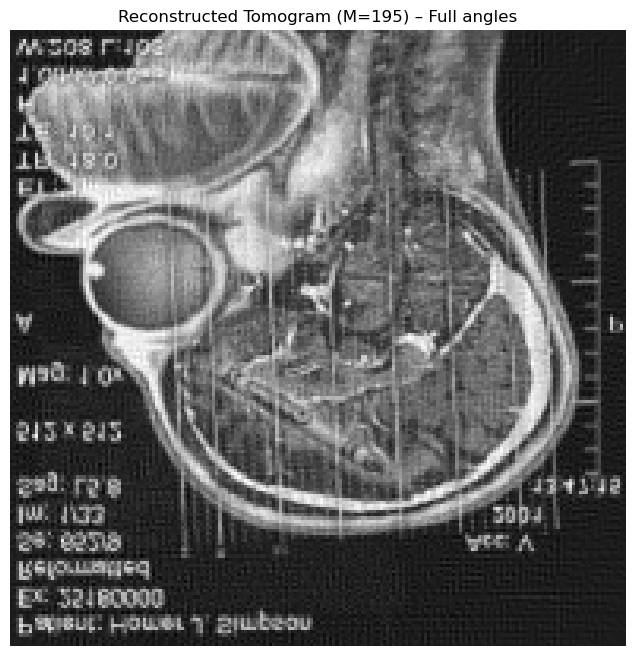

In [85]:
alphas_195 = np.load('./hs_tomography/alphas_195.npy')
y_195 = np.load('./hs_tomography/y_195.npy')

M_big = 195
Np_big = 275

print(f"Large image: {M_big} x {M_big}")
print(f"Angles: {len(alphas_195)}")
print(f"Measurements: {len(y_195)}")

# Build X (this may take ~20-30 seconds and use ~500 MB RAM)
print("\nBuilding X for large dataset: ")
start = time.time()
X_big = construct_X(M_big, alphas_195, Np_big)
print(f"Done in {time.time()-start:.1f} seconds.")
print(f"Non-zeros: {X_big.nnz}")
print(f"Sparsity: {1 - X_big.nnz / (X_big.shape[0]*X_big.shape[1]):.4%}")

# Solve (with higher tolerance for speed – reduce later if you want)
print("\nSolving large system ...")
start = time.time()
beta_big, istop, itn, r1norm, r2norm, anorm, acond, arnorm, xnorm, var = lsqr(
    X_big, y_195, atol=1e-5, btol=1e-5
)
print(f"Solved in {time.time()-start:.1f} seconds.")

img_big = beta_big.reshape(M_big, M_big)

plt.figure(figsize=(8, 8))
plt.imshow(img_big, cmap='gray')
plt.title("Reconstructed Tomogram (M=195) – Full angles")
plt.axis('off')
plt.show()

#### Now I want to use different angles to answer the last part of task 2 and task 3

# Task 3 - Minimizing the radiation dose

In [86]:
alphas_195 = np.load('./hs_tomography/alphas_195.npy')
y_195 = np.load('./hs_tomography/y_195.npy')
M_big = 195
Np_big = 275

all_angles = alphas_195.copy()
y_full = y_195.copy()

In [87]:
# angles counts to test
fractions = [1.0, 0.5, 0.3, 0.2, 0.1]   # 179, 90, 54, 36, 18
extra_ang = [10, 6]

n_angles_list = []

for i in fractions:
    n_angles_list.append(int(i * len(all_angles)))

n_angles_list.extend(extra_ang)


In [88]:
# remove the duplicates and sort the list of angles counts
n_angles_list = sorted(set(n_angles_list), reverse=True)

print(f"Number of angles to test: {n_angles_list}")

Number of angles to test: [179, 89, 53, 35, 17, 10, 6]


Building X for 179 angles: 
Building X for 89 angles: 
Building X for 53 angles: 
Building X for 35 angles: 
Building X for 17 angles: 
Building X for 10 angles: 
Building X for 6 angles: 


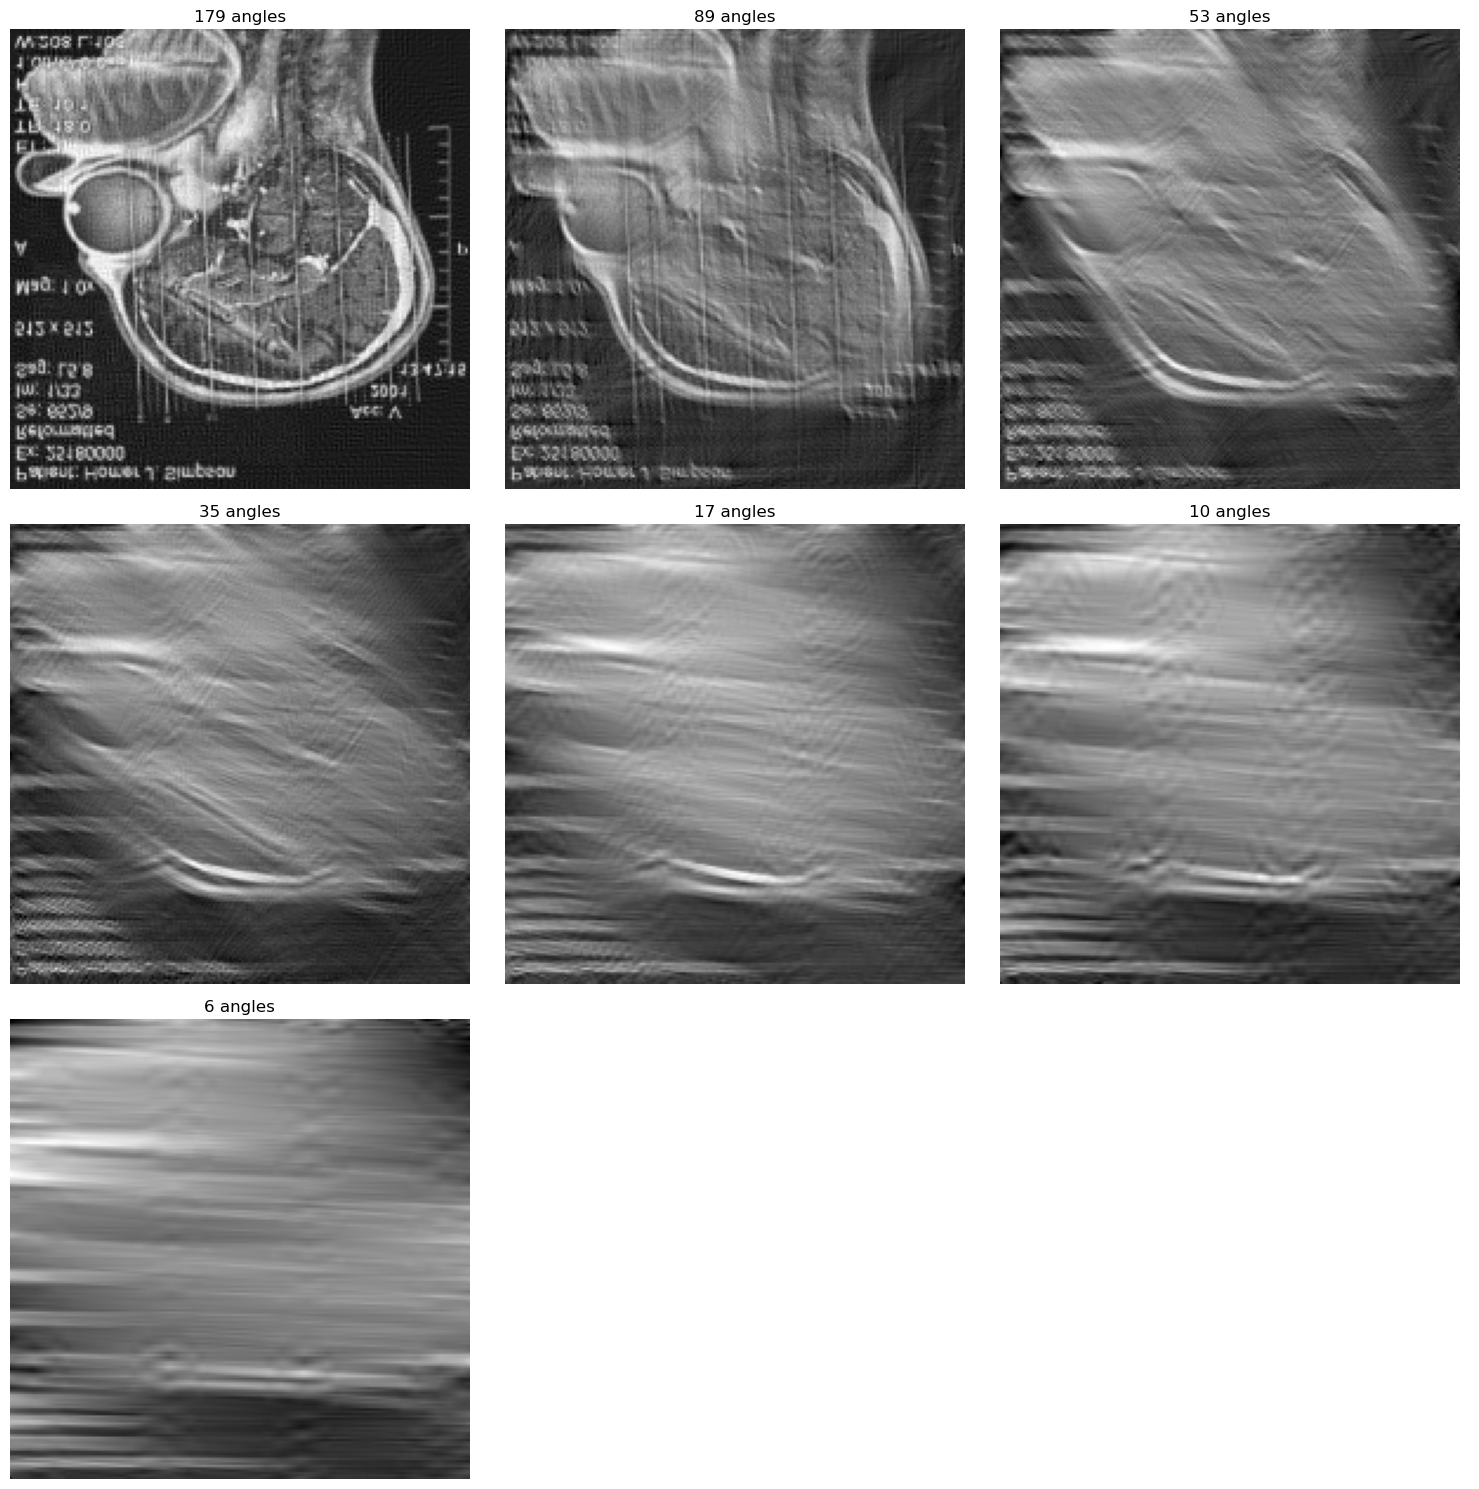

In [89]:
n_plots = len(n_angles_list)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.ravel()


for idx, n_angles in enumerate(n_angles_list):
    subset_alphas = all_angles[:n_angles]
    print(f"Building X for {n_angles} angles: ")
    X_sub = construct_X(M_big, subset_alphas, Np_big)
    y_sub = y_full[:n_angles * Np_big]

    # solve equation system
    beta_sub, _, _, _, _, _, _, _, _, _ = lsqr(X_sub, y_sub, atol=1e-5, btol=1e-5)
    img_sub = beta_sub.reshape(M_big, M_big)

    ax = axes[idx]
    ax.imshow(img_sub, cmap='gray')
    ax.set_title(f"{n_angles} angles")
    ax.axis('off')

for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

of course `179` angles is the best quality here that we can get and we may be able to recognize the patients problem. But as a doctor not wanting too many radion angles at patient, I would recommend sth between 120.